In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

**<font size="6" color="red">ch4.RNN(Recurrent Neural Network)</font>**
- 순서나 시간 데이터가 중요할 때 ex. 번역, 음성인식, 주가예측

# 1. 문맥을 이용하여 모델만들기

In [18]:
text = """경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다"""
text1 = "겨울이 오는 날"

In [19]:
from keras_preprocessing.text import Tokenizer
t = Tokenizer()
t.fit_on_texts([text, text1])
encoded = t.texts_to_sequences([text, text1])
print(encoded)
print(t.word_index)

[[3, 4, 1, 5, 6, 7, 1, 8, 9, 1, 10, 2, 1, 11], [12, 2, 13]]
{'말이': 1, '오는': 2, '경마장에': 3, '있는': 4, '뛰고': 5, '있다': 6, '그의': 7, '법이다': 8, '가는': 9, '고와야': 10, '곱다': 11, '겨울이': 12, '날': 13}


In [20]:
text = """경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다"""

In [21]:
# 문자를 인덱스 시퀀스로 변환하기 위한 과정
t = Tokenizer()
t.fit_on_texts([text])
print(t.word_index)

{'말이': 1, '경마장에': 2, '있는': 3, '뛰고': 4, '있다': 5, '그의': 6, '법이다': 7, '가는': 8, '고와야': 9, '오는': 10, '곱다': 11}


In [22]:
# 문자열 리스트를 인덱스 시퀀스로 변환
print(t.texts_to_sequences(['경마장에 말이 있다','말이 뛴다']))
print(t.texts_to_sequences(['가는 말이 곱다'])[0])

[[2, 1, 5], [1]]
[8, 1, 11]


In [23]:
for key, value in t.word_index.items():
    print(key, value)

말이 1
경마장에 2
있는 3
뛰고 4
있다 5
그의 6
법이다 7
가는 8
고와야 9
오는 10
곱다 11


In [24]:
text =  """경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다"""

In [26]:
# text를 학습시키기 위한 ['경마장에 있는', '경마장에 있는 말이', ....]
sequences = []
for line in text.split('\n'):
    print('원 문장 : ',line)
    encoded = t.texts_to_sequences([line])[0]
    print('encoded된 문장 :', encoded)
    for i in range(0, len(encoded)-1): # 시작index
        for j in range(i+2, len(encoded)+1 ): # 끝나는 index
            sequences.append(encoded[i:j])
#sequences
print('sequences와 해석 출력')
for sequence in sequences:
    # print(sequence)
    for word_seq in sequence:
        for key, value in t.word_index.items():
            if word_seq==value:
                print("{}:{}".format(word_seq, key), end=' ')
                break
    print()

원 문장 :  경마장에 있는 말이 뛰고 있다
encoded된 문장 : [2, 3, 1, 4, 5]
원 문장 :  그의 말이 법이다
encoded된 문장 : [6, 1, 7]
원 문장 :  가는 말이 고와야 오는 말이 곱다
encoded된 문장 : [8, 1, 9, 10, 1, 11]
sequences와 해석 출력
2:경마장에 3:있는 
2:경마장에 3:있는 1:말이 
2:경마장에 3:있는 1:말이 4:뛰고 
2:경마장에 3:있는 1:말이 4:뛰고 5:있다 
3:있는 1:말이 
3:있는 1:말이 4:뛰고 
3:있는 1:말이 4:뛰고 5:있다 
1:말이 4:뛰고 
1:말이 4:뛰고 5:있다 
4:뛰고 5:있다 
6:그의 1:말이 
6:그의 1:말이 7:법이다 
1:말이 7:법이다 
8:가는 1:말이 
8:가는 1:말이 9:고와야 
8:가는 1:말이 9:고와야 10:오는 
8:가는 1:말이 9:고와야 10:오는 1:말이 
8:가는 1:말이 9:고와야 10:오는 1:말이 11:곱다 
1:말이 9:고와야 
1:말이 9:고와야 10:오는 
1:말이 9:고와야 10:오는 1:말이 
1:말이 9:고와야 10:오는 1:말이 11:곱다 
9:고와야 10:오는 
9:고와야 10:오는 1:말이 
9:고와야 10:오는 1:말이 11:곱다 
10:오는 1:말이 
10:오는 1:말이 11:곱다 
1:말이 11:곱다 


In [28]:
# sequences의 길이를 모두 같게(padding)
my_len = max([len(seq) for seq in sequences])
my_len

6

In [32]:
# sequences를 훈련 가능하도록 6개(앞에 0, 뒤에 0)
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences = pad_sequences(sequences=sequences,
                                 maxlen=my_len,
                                 padding='pre', # 앞에 0을 padding
                                 # truncating='post', 
                                )
padded_sequences[:3]

array([[0, 0, 0, 0, 2, 3],
       [0, 0, 0, 2, 3, 1],
       [0, 0, 2, 3, 1, 4]])

In [34]:
# 독립변수(X)와 타겟변수(y)를 분리
X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]
# 단어 갯수
vocab_size = len(t.word_index)
vocab_size

11

In [35]:
# 종속변수의 원핫인코딩
from tensorflow.keras.utils import to_categorical
Y = to_categorical(y, vocab_size+1)
Y[:3]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [36]:
X.shape, Y.shape, vocab_size

((28, 5), (28, 12), 11)

In [37]:
# 모델 생성 ( Embedding -> RNN -> Dense층 )
# Embedding층의 입력은 12(희소행렬) -> 출력은 10. 이 단계에서 필요한 Embedding weight matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
# 교안 106p.
model = Sequential(name='sequential')
model.add(Embedding(input_dim=vocab_size+1, # 임베딩 입력
                   output_dim=10, # 임베딩 출력
                   input_length=X.shape[1])) # 입력(독립)변수 단어 길이
model.add(SimpleRNN(32, activation='tanh')) # 기본 activation='tanh'
model.add(Dense(12, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 5, 10)             120       
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                1376      
                                                                 
 dense (Dense)               (None, 12)                396       
                                                                 
Total params: 1,892
Trainable params: 1,892
Non-trainable params: 0
_________________________________________________________________


In [39]:
# 학습과정 설정
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
# 학습시키기
hist = model.fit(X, Y, epochs=300, verbose=2)

Epoch 1/300
1/1 - 2s - loss: 2.4679 - accuracy: 0.1071 - 2s/epoch - 2s/step
Epoch 2/300
1/1 - 0s - loss: 2.4548 - accuracy: 0.0714 - 3ms/epoch - 3ms/step
Epoch 3/300
1/1 - 0s - loss: 2.4416 - accuracy: 0.1786 - 6ms/epoch - 6ms/step
Epoch 4/300
1/1 - 0s - loss: 2.4283 - accuracy: 0.2500 - 6ms/epoch - 6ms/step
Epoch 5/300
1/1 - 0s - loss: 2.4148 - accuracy: 0.2857 - 4ms/epoch - 4ms/step
Epoch 6/300
1/1 - 0s - loss: 2.4010 - accuracy: 0.3214 - 5ms/epoch - 5ms/step
Epoch 7/300
1/1 - 0s - loss: 2.3869 - accuracy: 0.3214 - 4ms/epoch - 4ms/step
Epoch 8/300
1/1 - 0s - loss: 2.3723 - accuracy: 0.3214 - 3ms/epoch - 3ms/step
Epoch 9/300
1/1 - 0s - loss: 2.3572 - accuracy: 0.3214 - 4ms/epoch - 4ms/step
Epoch 10/300
1/1 - 0s - loss: 2.3416 - accuracy: 0.2857 - 4ms/epoch - 4ms/step
Epoch 11/300
1/1 - 0s - loss: 2.3255 - accuracy: 0.2857 - 5ms/epoch - 5ms/step
Epoch 12/300
1/1 - 0s - loss: 2.3088 - accuracy: 0.2857 - 3ms/epoch - 3ms/step
Epoch 13/300
1/1 - 0s - loss: 2.2914 - accuracy: 0.2857 - 5ms/e

Epoch 105/300
1/1 - 0s - loss: 1.0732 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 106/300
1/1 - 0s - loss: 1.0636 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 107/300
1/1 - 0s - loss: 1.0541 - accuracy: 0.7143 - 3ms/epoch - 3ms/step
Epoch 108/300
1/1 - 0s - loss: 1.0446 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 109/300
1/1 - 0s - loss: 1.0353 - accuracy: 0.7143 - 2ms/epoch - 2ms/step
Epoch 110/300
1/1 - 0s - loss: 1.0261 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 111/300
1/1 - 0s - loss: 1.0171 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 112/300
1/1 - 0s - loss: 1.0081 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 113/300
1/1 - 0s - loss: 0.9992 - accuracy: 0.7143 - 5ms/epoch - 5ms/step
Epoch 114/300
1/1 - 0s - loss: 0.9904 - accuracy: 0.7143 - 3ms/epoch - 3ms/step
Epoch 115/300
1/1 - 0s - loss: 0.9817 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 116/300
1/1 - 0s - loss: 0.9731 - accuracy: 0.7143 - 5ms/epoch - 5ms/step
Epoch 117/300
1/1 - 0s - loss: 0.9645 - 

Epoch 208/300
1/1 - 0s - loss: 0.4620 - accuracy: 0.8571 - 5ms/epoch - 5ms/step
Epoch 209/300
1/1 - 0s - loss: 0.4589 - accuracy: 0.8571 - 6ms/epoch - 6ms/step
Epoch 210/300
1/1 - 0s - loss: 0.4558 - accuracy: 0.8571 - 3ms/epoch - 3ms/step
Epoch 211/300
1/1 - 0s - loss: 0.4528 - accuracy: 0.8571 - 3ms/epoch - 3ms/step
Epoch 212/300
1/1 - 0s - loss: 0.4498 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 213/300
1/1 - 0s - loss: 0.4468 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 214/300
1/1 - 0s - loss: 0.4439 - accuracy: 0.8571 - 7ms/epoch - 7ms/step
Epoch 215/300
1/1 - 0s - loss: 0.4410 - accuracy: 0.8571 - 3ms/epoch - 3ms/step
Epoch 216/300
1/1 - 0s - loss: 0.4381 - accuracy: 0.8929 - 7ms/epoch - 7ms/step
Epoch 217/300
1/1 - 0s - loss: 0.4353 - accuracy: 0.8929 - 4ms/epoch - 4ms/step
Epoch 218/300
1/1 - 0s - loss: 0.4325 - accuracy: 0.8929 - 2ms/epoch - 2ms/step
Epoch 219/300
1/1 - 0s - loss: 0.4298 - accuracy: 0.8929 - 3ms/epoch - 3ms/step
Epoch 220/300
1/1 - 0s - loss: 0.4270 - 

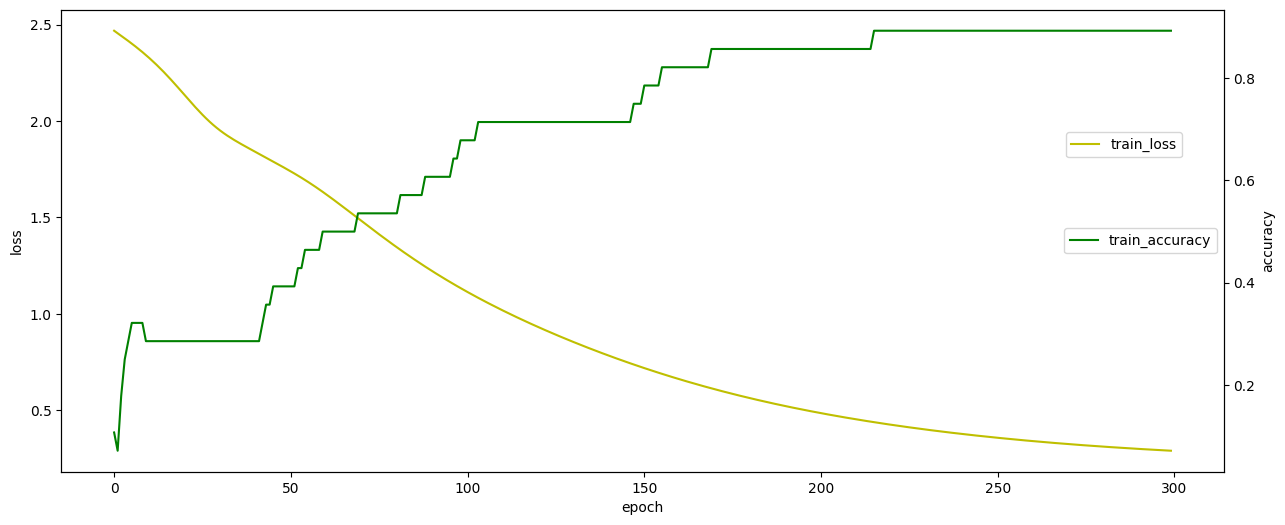

In [40]:
# 학습과정 살펴보기(시각화)
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [42]:
# 모델 사용하기(경마장에 있는 -> 말이)
from tensorflow.keras.preprocessing.sequence import pad_sequences
encoded = t.texts_to_sequences(['경마장에 있는'])[0]
input_data = pad_sequences([encoded], maxlen=5, padding='pre')
print('모델에 들어갈 입력 데이터 :',input_data)
result = model.predict(input_data).argmax(axis=1)[0]
print('모델 예측 결과 :', result)
for key, value in t.word_index.items():
    if value==result:
        print('가장 확률이 높은 단어(예측딘 단어) :', key)
        break

모델에 들어갈 입력 데이터 : [[0 0 0 2 3]]
1/1 [==============================] - 0s 289ms/step
모델 예측 결과 : 1
가장 확률이 높은 단어(예측딘 단어) : 말이


# 2. 다음 문맥 예측해 보기

In [43]:
# '가는 말이' 이후에 올 단어 4개 예측
def sentence_generation(model, t, current_word, n):
    print('입력된 단어 :', current_word)
    for i in range(1, n+1):
        encoded = t.texts_to_sequences([current_word])[0]
        input_data = pad_sequences([encoded], maxlen=5, padding='pre')
        result = model.predict(input_data, verbose=0).argmax(axis=1)[0]
        for key, value in t.word_index.items():
            if value==result:
                print(f'{i}번째 {key}:{result}')
                current_word = current_word + ' ' + key
                break
    return current_word

In [44]:
sentence_generation(model, t, '경마장에', 4)

입력된 단어 : 경마장에
1번째 있는:3
2번째 말이:1
3번째 뛰고:4
4번째 있다:5


'경마장에 있는 말이 뛰고 있다'